# CAIPH Datathon: Stroke Prediction Dataset
Author: Annika Cleven (ed: Vincent Toups)
Date: 2026-02-04

Research Question:

Can we identify meaningful sub-groups in stroke victims?

Welcome the CAIPH Datathon!

You are looking at A Stroke Dataset provided by user fedesoriano on
Kaggle. The paper "Predictive modelling and identification of key risk
factors for stroke using machine learning" by Ahmad Hassan, Saima
Gulzar Ahmad, Ehsan Ullah Munir, Imtiaz Ali Khan & Naeem Ramzan
available [here](https://www.nature.com/articles/s41598-024-61665-4#Sec3) provides a good
introduction to the data set and might be a place to look for ideas
about how to proceed with analysis. It describes the data set like this:

> The stroke prediction dataset was created by McKinsey & Company and Kaggle is the source of the data used in this study38,39. The dataset is in comma separated values (CSV) format, including demographic and health-related information about individuals and whether or not they have had a stroke. The dataset was originally comprised a total of 29,072 records, while only 30% of the data is publicly accessible and the remaining 70% is designated as private. The source of the dataset is mentioned as confidential. The data originates from medical records associated with 5110 individuals residing in Bangladesh. The dataset has underwent preprocessing procedures, which involved modifications to the original dataset sourced from Electronic Health Records (EHR) managed by McKinsey & Company. The data has some missing values, and there is an imbalance between the number of people who have had a stroke and those who have not. The aim is to address these issues using different data imputation techniques and oversampling methods.


## Setup

In [4]:
# Load required packages (add others as needed)
install.packages(c("themis"))

library(tidyverse)
library(knitr)
library(factoextra)
library(tidymodels)
library(themis)


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘RANN’, ‘ROSE’




The data itself is located in this directory. And we can load it and look at it just like this:

In [6]:
stroke <- read_csv("/data/stroke/healthcare-dataset-stroke-data.csv")
stroke

Rows: 5110 Columns: 12
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (6): gender, ever_married, work_type, Residence_type, bmi, smoking_status
dbl (6): id, age, hypertension, heart_disease, avg_glucose_level, stroke

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>
9046,Male,67,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
51676,Female,61,0,0,Yes,Self-employed,Rural,202.21,N/A,never smoked,1
31112,Male,80,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
60182,Female,49,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
1665,Female,79,1,0,Yes,Self-employed,Rural,174.12,24,never smoked,1
56669,Male,81,0,0,Yes,Private,Urban,186.21,29,formerly smoked,1
53882,Male,74,1,1,Yes,Private,Rural,70.09,27.4,never smoked,1
10434,Female,69,0,0,No,Private,Urban,94.39,22.8,never smoked,1
27419,Female,59,0,0,Yes,Private,Rural,76.15,N/A,Unknown,1


## Tidying up and Preliminary Examination

We often have to tidy up the data. Here we are fixing a few issues with how missing data is encoded and creating 
factor variables, which is how we tell R that we have categorical variables instead of just raw text.


In [7]:
stroke2 <- stroke %>% 
  mutate(across(where(is.character), as.factor),
         across(where(is.logical), as.factor)) %>%
  mutate(bmi = ifelse(bmi == "N/A", NA, bmi)) %>%
  mutate(bmi = as.numeric(bmi),
         hypertension = as.factor(hypertension),
         heart_disease = as.factor(heart_disease),
         stroke = as.factor(stroke))
 
stroke_counts <- stroke2 %>%
  select(where(~ is.factor(.) | is.character(.))) %>%
  pivot_longer(everything(),
               names_to = "variable",
               values_to = "category") %>%
  count(variable, category, name = "n") %>%
  arrange(variable, desc(n))

stroke_counts

variable,category,n
<chr>,<fct>,<int>
Residence_type,Urban,2596
Residence_type,Rural,2514
ever_married,Yes,3353
ever_married,No,1757
gender,Female,2994
gender,Male,2115
gender,Other,1
heart_disease,0,4834
heart_disease,1,276


Note that this data is highly imbalanced, since most people have not had a stroke in this data set.

Warning message in geom_histogram(stat = "count", fill = "blue"):
“Ignoring unknown parameters: `binwidth` and `bins`”


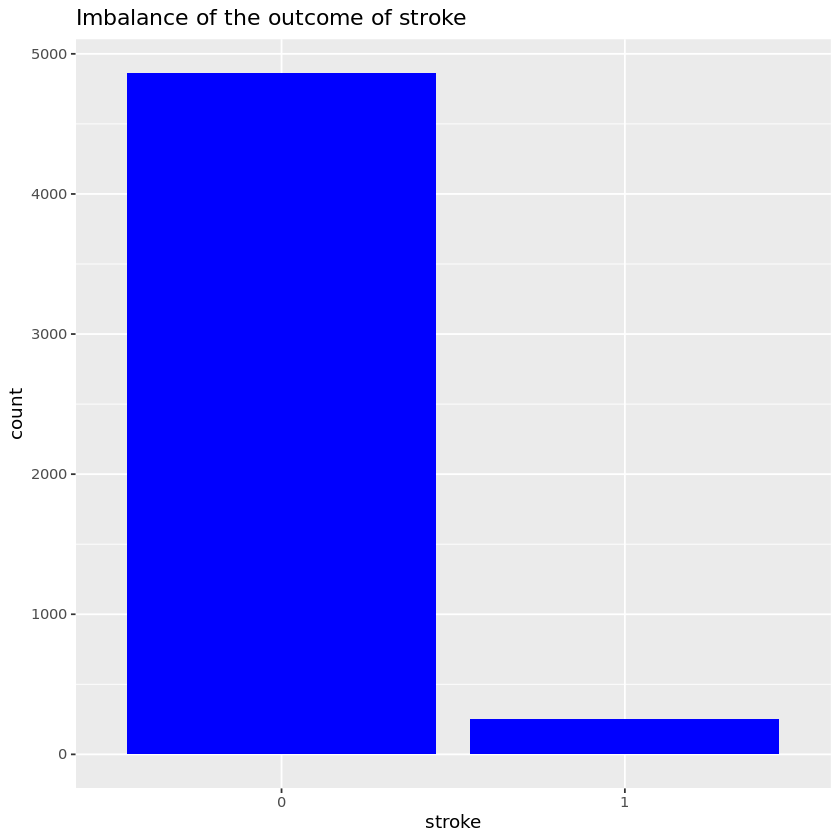

In [8]:
stroke2 %>% 
  ggplot(aes(stroke))+ 
  geom_histogram(stat = "count", fill = "blue")+
  labs(title = "Imbalance of the outcome of stroke")

Let's make a few bar chards showing risk factors against stroke.

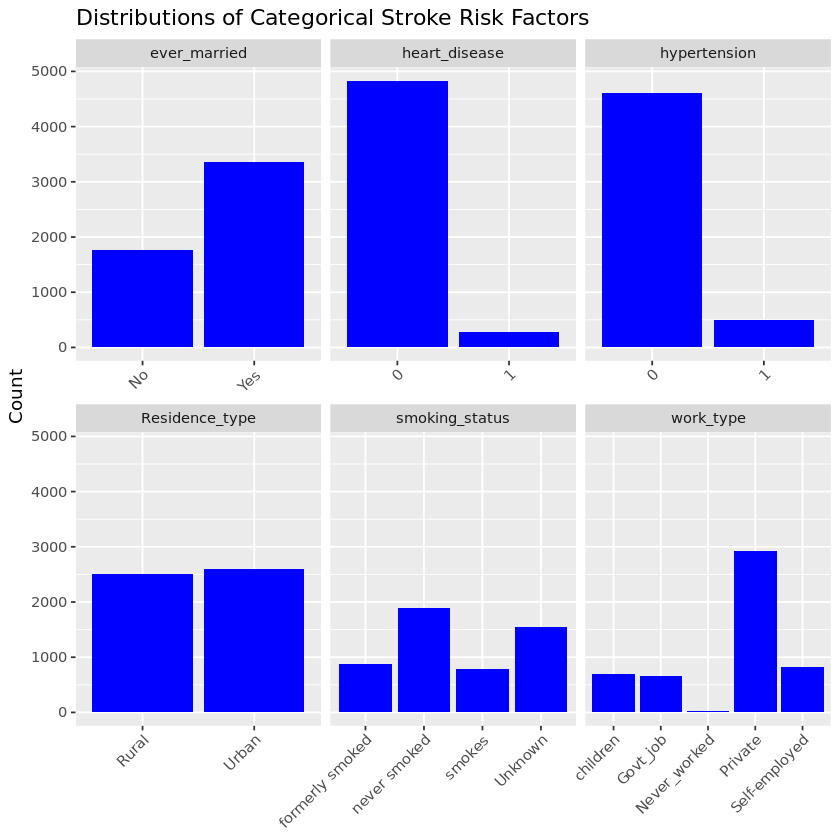

In [9]:
stroke2 %>%
  select(Residence_type, ever_married, heart_disease,
         hypertension, work_type, smoking_status) %>%
  pivot_longer(everything(),
               names_to = "variable",
               values_to = "category") %>%
  ggplot(aes(x = category)) +
  geom_bar(fill = "blue") +
  facet_wrap(~ variable, scales = "free_x") +
  labs(
    title = "Distributions of Categorical Stroke Risk Factors",
    x = NULL,
    y = "Count"
  ) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1)
  )

And calculate how much data is missing.

In [12]:
missing_summary <- stroke2 %>%
  summarise(across(everything(),
                   ~ sum(is.na(.)),
                   .names = "na_{col}")) %>%
  pivot_longer(everything(),
               names_to = "variable",
               values_to = "n_missing")

missing_summary %>%
  filter(n_missing > 0) %>%
  mutate(pct_missing = n_missing / nrow(stroke) * 100) %>%
  kable()

missing_summary



|variable | n_missing| pct_missing|
|:--------|---------:|-----------:|
|na_bmi   |       201|    3.933464|

variable,n_missing
<chr>,<int>
na_id,0
na_gender,0
na_age,0
na_hypertension,0
na_heart_disease,0
na_ever_married,0
na_work_type,0
na_Residence_type,0
na_avg_glucose_level,0


And we can also quickly get a sense for the numerical variable ranges.

In [13]:
stroke2 %>%
  select(where(is.numeric)) %>%
  summary()

       id             age        avg_glucose_level      bmi       
 Min.   :   67   Min.   : 0.08   Min.   : 55.12    Min.   :  1.0  
 1st Qu.:17741   1st Qu.:25.00   1st Qu.: 77.25    1st Qu.:109.0  
 Median :36932   Median :45.00   Median : 91.89    Median :155.0  
 Mean   :36518   Mean   :43.23   Mean   :106.15    Mean   :162.1  
 3rd Qu.:54682   3rd Qu.:61.00   3rd Qu.:114.09    3rd Qu.:205.0  
 Max.   :72940   Max.   :82.00   Max.   :271.74    Max.   :418.0  
                                                   NA's   :201    

## PCA

I like to say that all data science is just dimensionality reduction, since we are looking for relationships between the variables that we can
use to describe the data in a simpler way. Let's try "old reliable," principal component analysis.

If you've never done PCA before, the idea is simple - we want to find linear combinations of variables which vary in decreasing order. This really only makes sense for continuous data.

Warning message in geom_bar(stat = "identity", fill = barfill, color = barcolor, :
“Ignoring empty aesthetic: `width`.”


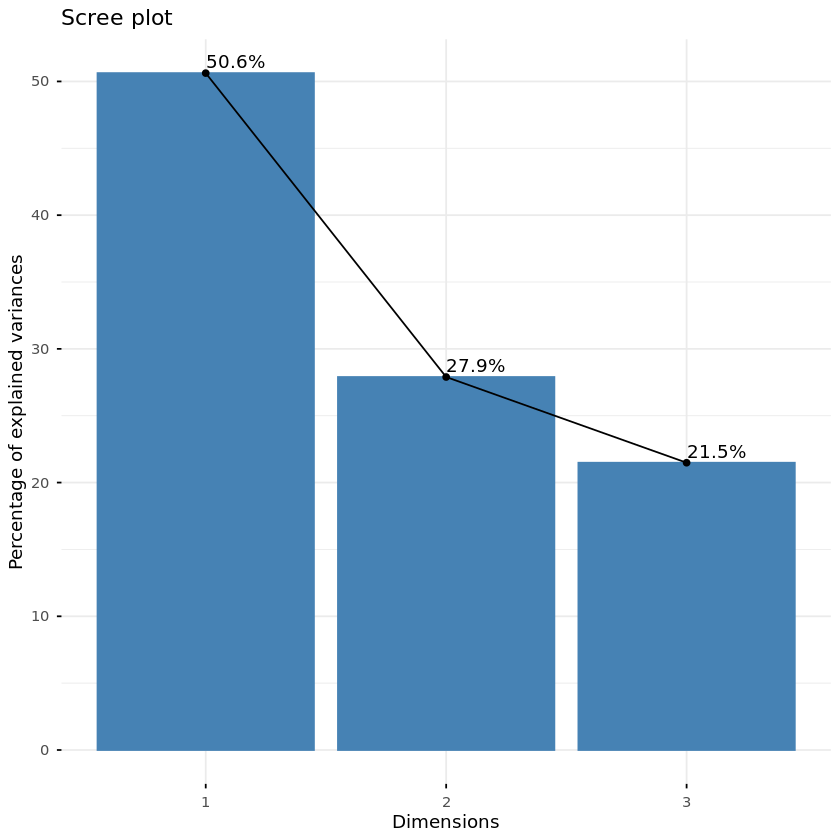

In [14]:
stroke_pca <- stroke2 %>%
  filter(is.na(bmi) != T) %>%
  select(-id) %>%                # drop ID              # bmi has missing values
  select(where(is.numeric))
  
  
#standardize  
pca_fit <- prcomp(
  stroke_pca,
  center = TRUE,
  scale. = TRUE
)

fviz_eig(pca_fit, addlabels = TRUE)

What we see is that the first three components constitute a large amount of the variation in the data, which we would expect, given that these variables should be correlated.

We can loading plot to show how different variables in the data set contribute to each component. Here we are looking at just the first two components. We read this plot roughly like "an increase in glucose level" moves us both along PC1 and PC2, but age moves us mostly along PC1.

Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the factoextra package.
  Please report the issue at <https://github.com/kassambara/factoextra/issues>.”
Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
ℹ The deprecated feature was likely used in the factoextra package.
  Please report the issue at <https://github.com/kassambara/factoextra/issues>.”


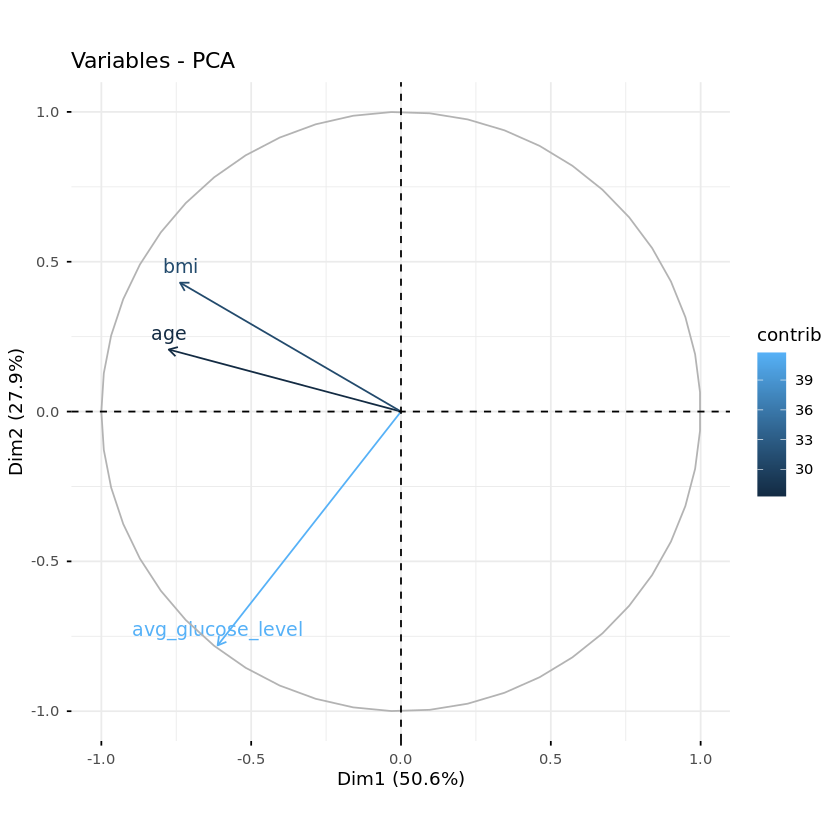

In [15]:
fviz_pca_var(
  pca_fit,
  col.var = "contrib"
)

We can also just plot our data in the principal component space.

Note, that this amounts to just rotating our data. The points are all the same distances from one another as they were before we plotted them in principal component space. The benefit of this tranformation is that we can "throw away" the small components.

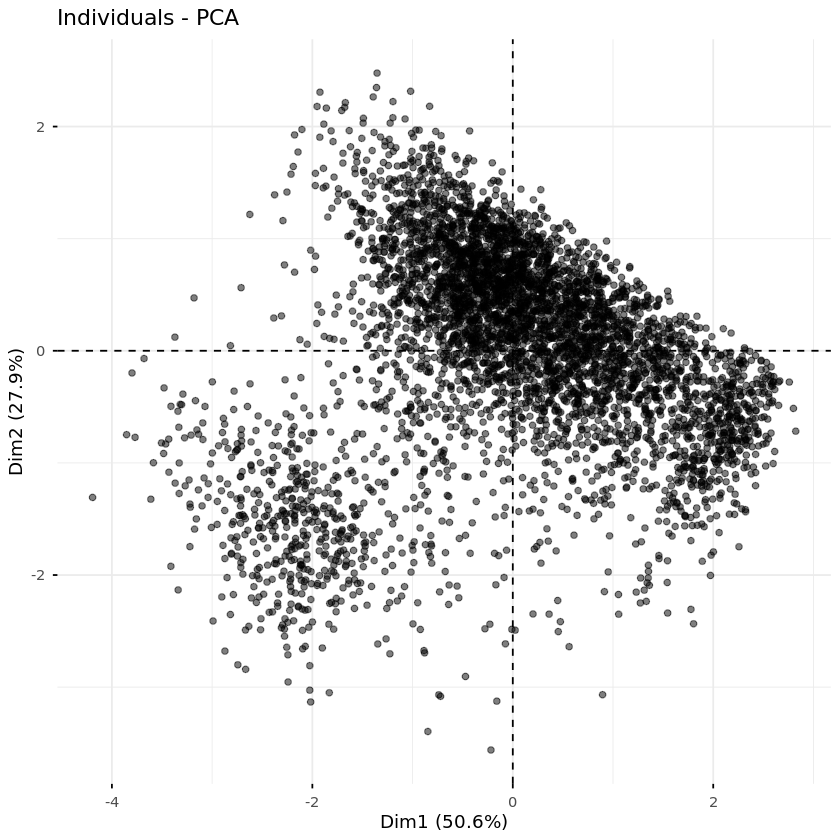

In [16]:
fviz_pca_ind(
  pca_fit,
  geom = "point",
  alpha.ind = 0.5
)

We can now color code the points by whether the subject has had a stroke or not and see that while there is substantial overlap, stroke victims live in smaller region of this space.

Ignoring unknown labels:
• linetype : "Stroke"


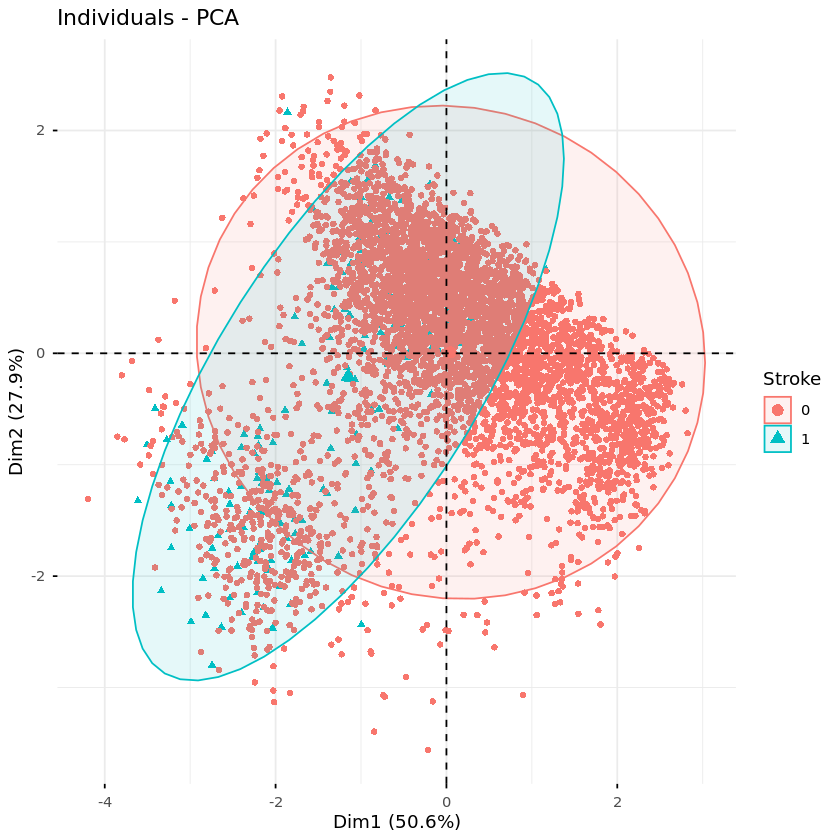

In [17]:
fviz_pca_ind(
  pca_fit,
  geom = "point",
  habillage = stroke2 %>% drop_na(bmi) %>% pull(stroke),
  addEllipses = TRUE,
  legend.title = "Stroke"
)

## CLUSTERING

It seems like there are clusters in the above plot. Can we find them? Let's do some clustering. This code uses a "kmeans" clustering with a heuristic for selecting the number of clusters.

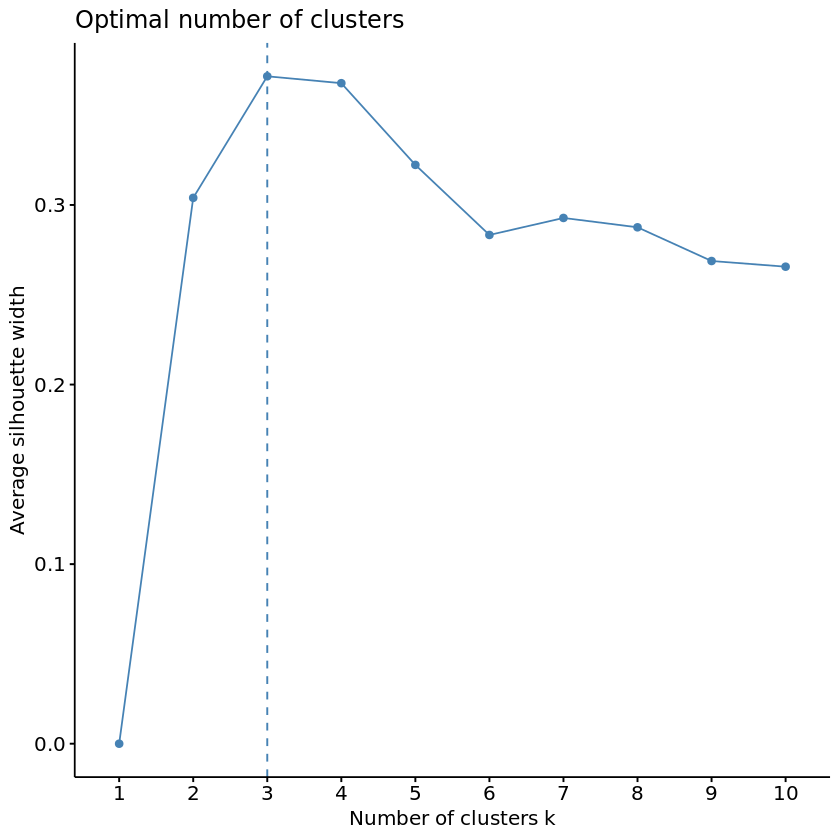

In [21]:
set.seed(123)

pc_scores <- as_tibble(pca_fit$x[, 1:3])
fviz_nbclust(
  pc_scores,
  kmeans,
  method = "silhouette"
)

Now we can do a clustering with that number of clusters and show a color coded plot:

Joining with `by = join_by(age, avg_glucose_level, bmi)`


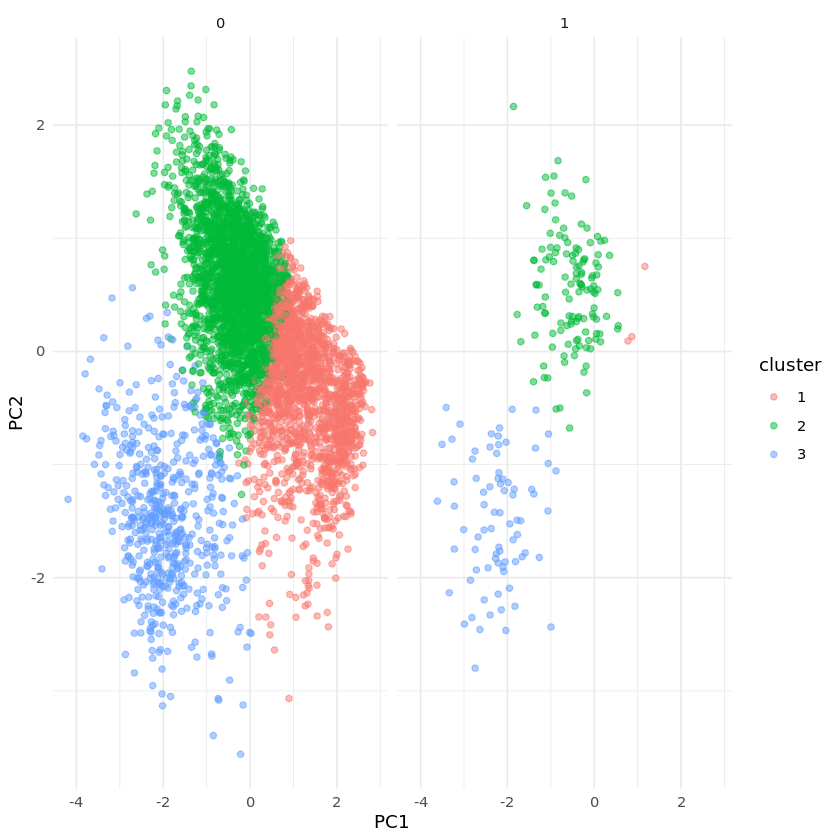

In [22]:
kmeans_fit <- kmeans(
  pc_scores,
  centers = 3,
  nstart = 50
)

stroke_clustered <- stroke_pca %>%
  bind_cols(pc_scores) %>%
  mutate(cluster = factor(kmeans_fit$cluster)) %>%
  left_join(stroke2)

ggplot(
  stroke_clustered,
  aes(PC1, PC2, color = cluster)
) +
  geom_point(alpha = 0.5) +
  facet_wrap(~ stroke) +
  theme_minimal()

Let's do some modeling. We are going to do a train test split and use everything except the stroke variable itself to predict stroke, and then train a random forest. We'll comment less from here on out, but after you run this code you could try some other methods of building a model. The random forest does great, but is it overfit? How does a regular ol' logistic regression or CART tree perform?

In [24]:
stroke_split <- initial_split(
  stroke2 %>% filter(is.na(bmi) == F),
  prop = 0.8,
  strata = stroke
)

stroke_train <- training(stroke_split) %>%
  mutate(stroke = factor(stroke, levels = c("1", "0")))
stroke_test  <- testing(stroke_split) %>%
  mutate(stroke = factor(stroke, levels = c("1", "0")))

In [25]:
stroke_recipe <- recipe(stroke ~ ., data = stroke_train) %>%
  step_dummy(all_nominal_predictors()) %>%
  step_zv(all_predictors()) %>%
  step_normalize(all_numeric_predictors()) %>%
  step_smote(stroke)

In [30]:
#rf 
rf_spec <- rand_forest(
  trees = 500,
  mtry = tune(),
  min_n = tune()
) %>%
  set_engine("ranger", importance = "impurity") %>%
  set_mode("classification")

In [27]:
rf_wf <- workflow() %>%
  add_recipe(stroke_recipe) %>%
  add_model(rf_spec)|

In [31]:
set.seed(123)
#folds
install.packages("ranger")
folds <- vfold_cv(stroke_train, v = 5, strata = stroke) 
#tuning
rf_tuned <- tune_grid(
  rf_wf,
  resamples = folds,
  metrics = metric_set(roc_auc),
  grid = 10
)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

i Creating pre-processing data to finalize 1 unknown parameter: "mtry"

→ A | warning: ! 17 columns were requested but there were 16 predictors in the data.
               ℹ 16 predictors will be used.

There were issues with some computations   A: x1
There were issues with some computations   A: x1




In [32]:
#pull the best tuning metrics
best_rf <- select_best(
  rf_tuned,
  metric = "roc_auc"
)

# fit the best rf
final_rf_wf <- finalize_workflow(
  rf_wf,
  best_rf
)

# fit the model on training
final_rf_fit <- fit(
  final_rf_wf,
  data = stroke_train
)

# predict on testing    
rf_preds <- predict(
  final_rf_fit,
  stroke_test,
  type = "prob"
) %>%
  bind_cols(stroke_test)

# auc
roc_auc(
  rf_preds,
  truth = stroke,
  .pred_1
)

.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
roc_auc,binary,0.8246385


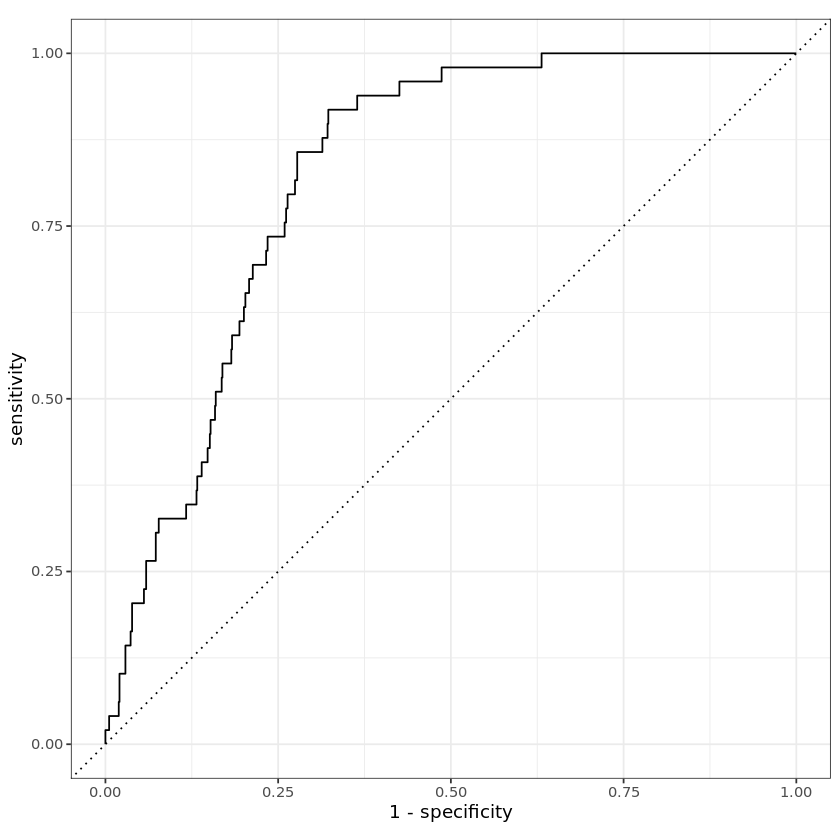

In [33]:
# plot roc curve
roc_curve(
  rf_preds,
  truth = stroke,
  .pred_1
) %>%
  autoplot()

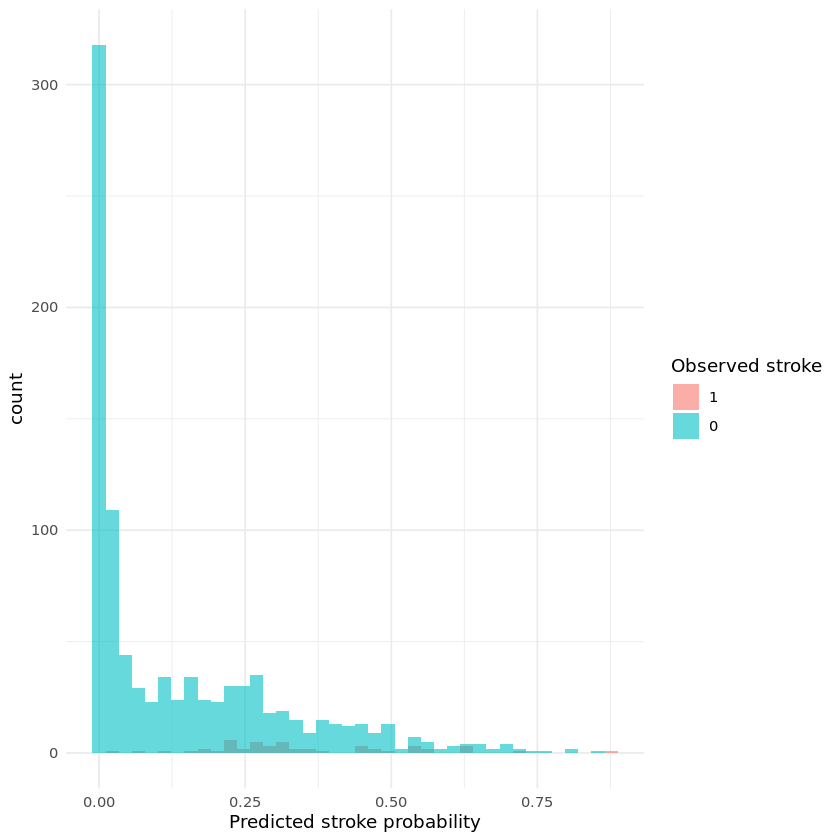

In [36]:
# plot predictions 
ggplot(
  rf_preds,
  aes(x = .pred_1, fill = stroke)
) +
  geom_histogram(
    bins = 40,
    alpha = 0.6,
    position = "identity"
  ) +
  labs(
    x = "Predicted stroke probability",
    fill = "Observed stroke"
  ) +
  theme_minimal()

In [37]:
rf_preds <- rf_preds %>%
  mutate(
    pred_class = factor(
      if_else(.pred_1 >= 0.5, "1", "0"),
      levels = c("1", "0")
    )
  ) %>% 
  mutate(
    pred_class2 = factor(
      if_else(.pred_1 >= 0.15, "1", "0"),
      levels = c("1", "0")
    )
  )

conf_mat(
  rf_preds,
  truth = stroke,
  estimate = pred_class
)

          Truth
Prediction   1   0
         1  10  41
         0  39 892

In [38]:
conf_mat(
  rf_preds,
  truth = stroke,
  estimate = pred_class2
)

          Truth
Prediction   1   0
         1  46 340
         0   3 593